# Laboratorio 8 — Etapa 4
## Efecto del intercambio de repetidas
## Diego Andre Calderon Salazar 241263 
## Pedro Julio Caso 241286

**MM3014 Teoría de Probabilidades — MA UVG**

---

## Contexto

Se introduce un mecanismo de intercambio: cada $K$ estampas repetidas se pueden canjear por 1 estampa nueva (a elegir entre las que faltan). El intercambio puede realizarse después de cada sobre. Se estudiará cómo varía el número esperado de sobres y la probabilidad de éxito al modificar $K$.

## Parámetros

- Álbum reducido: $N = 100$ estampas, $S = 7$ estampas por sobre
- Semilla: 2026
- Número de simulaciones por configuración: $R = 10{,}000$
- Valores de $K$ a explorar: $K = 1, 2, 5, 10$

## Importaciones y parámetros

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Parámetros globales
N = 100          # estampas en el álbum
S = 7            # estampas por sobre
R = 10_000       # simulaciones por configuración
SEED = 2026
K_VALUES = [1, 2, 5, 10]
PRECIO_SOBRE = 9.50

rng = np.random.default_rng(SEED)


---
## Parte A: Simulación hasta completar el álbum para distintos K

---

### A.1 — Función de simulación con intercambio

Escribir una función que simule el proceso de compra de sobres hasta completar el álbum, dado un valor de $K$ (número de repetidos necesarios para un canje).

In [5]:
def simular_con_intercambio(N, S, K, rng):
    album = np.zeros(N, dtype=bool)
    repetidos = 0
    sobres = 0

    while album.sum() < N:
        estampas = rng.integers(0, N, size=S)
        sobres += 1

        unique, counts = np.unique(estampas, return_counts=True)
        is_new = ~album[unique]
        album[unique[is_new]] = True
        repetidos += int((counts[is_new] - 1).sum() + counts[~is_new].sum())

        while repetidos >= K and album.sum() < N:
            faltantes = np.where(~album)[0]
            album[rng.choice(faltantes)] = True
            repetidos -= K

    return sobres


def simular_sin_intercambio(N, S, rng):
    album = np.zeros(N, dtype=bool)
    sobres = 0
    while album.sum() < N:
        album[rng.integers(0, N, size=S)] = True
        sobres += 1
    return sobres

### A.2 — Ejecutar R simulaciones para cada valor de K

Para cada valor de $K$ en la lista, realizar $R = 10{,}000$ simulaciones y calcular:
- Media y desviación estándar del número de sobres
- Reducción porcentual respecto al caso sin intercambio

In [3]:
resultados = {}

rng_ref = np.random.default_rng(SEED)
sobres_ref = np.array([simular_sin_intercambio(N, S, rng_ref) for _ in range(R)])
resultados[None] = sobres_ref
media_ref = sobres_ref.mean()
std_ref   = sobres_ref.std()

print(f"{'K':>5} | {'Media':>8} | {'Desv. Std':>10} | {'Reducción':>10}")
print("-" * 44)
print(f"{'∞':>5} | {media_ref:>8.2f} | {std_ref:>10.2f} | {'—':>10}")

for K in K_VALUES:
    rng_k = np.random.default_rng(SEED)
    datos = np.array([simular_con_intercambio(N, S, K, rng_k) for _ in range(R)])
    resultados[K] = datos
    media = datos.mean()
    std   = datos.std()
    red   = (1 - media / media_ref) * 100
    print(f"{K:>5} | {media:>8.2f} | {std:>10.2f} | {red:>9.1f}%")

    K |    Media |  Desv. Std |  Reducción
--------------------------------------------
    ∞ |    74.43 |      17.84 |          —
    1 |    15.00 |       0.00 |      79.8%
    2 |    20.03 |       0.54 |      73.1%
    5 |    28.56 |       1.46 |      61.6%
   10 |    35.89 |       2.44 |      51.8%


### A.3 — Visualización: histogramas superpuestos

Elaborar histogramas superpuestos para los diferentes valores de $K$.

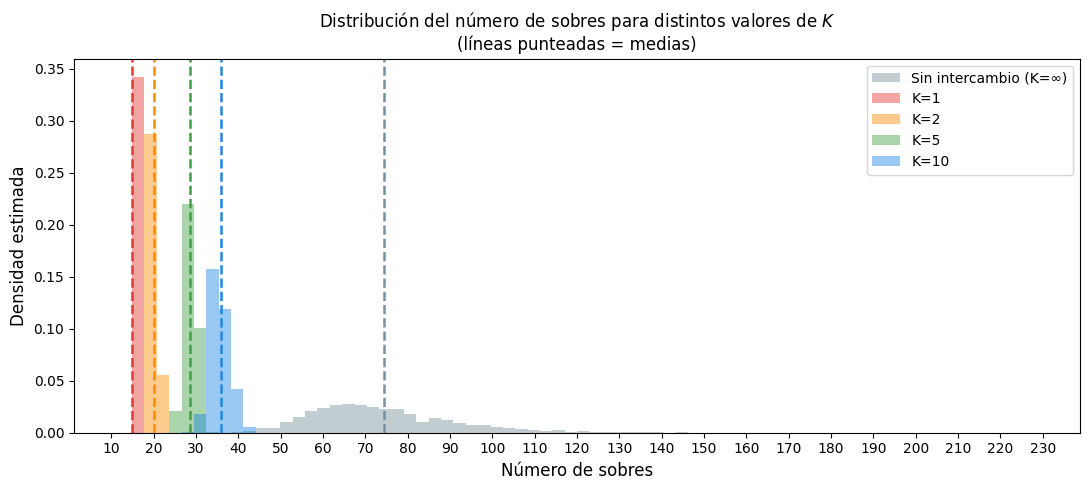

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

colores   = ['#78909C', '#E53935', '#FB8C00', '#43A047', '#1E88E5']
etiquetas = ['Sin intercambio (K=∞)', 'K=1', 'K=2', 'K=5', 'K=10']
datos_plot = [resultados[None]] + [resultados[k] for k in K_VALUES]

todas = np.concatenate(datos_plot)
bins  = np.linspace(todas.min() - 3, todas.max() + 3, 75)

for datos, label, color in zip(datos_plot, etiquetas, colores):
    ax.hist(datos, bins=bins, density=True, alpha=0.45, color=color, label=label)
    ax.axvline(datos.mean(), color=color, lw=1.8, ls='--')

ax.set_xlabel('Número de sobres', fontsize=12)
ax.set_ylabel('Densidad estimada', fontsize=12)
ax.set_title('Distribución del número de sobres para distintos valores de $K$\n(líneas punteadas = medias)', fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

---
## Parte B: Probabilidad de éxito en función del número de sobres M para distintos K

---

### B.1 — Simulación para M sobres fijos

Fijar la secuencia de números de sobres: $M = 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70$.

Para cada $K \in \{1, 2, 5, 10\}$ y para cada $M$: simular 10,000 veces la compra de exactamente $M$ sobres aplicando la regla de intercambio con el $K$ correspondiente; registrar la proporción de veces que se completa el álbum (probabilidad de éxito).

In [7]:
M_VALUES = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

def prob_exito_K(N, S, K, M_values, R, rng):
    max_M   = max(M_values)
    M_check = set(M_values)
    completados = {M: 0 for M in M_values}

    for _ in range(R):
        album     = np.zeros(N, dtype=bool)
        repetidos = 0
        completado = False

        for m in range(1, max_M + 1):
            if not completado:
                estampas = rng.integers(0, N, size=S)
                unique, counts = np.unique(estampas, return_counts=True)
                is_new = ~album[unique]
                album[unique[is_new]] = True

                if K is not None:
                    repetidos += int((counts[is_new] - 1).sum() + counts[~is_new].sum())
                    while repetidos >= K and album.sum() < N:
                        faltantes = np.where(~album)[0]
                        album[rng.choice(faltantes)] = True
                        repetidos -= K

                if album.sum() == N:
                    completado = True

            if m in M_check:
                completados[m] += int(completado)

    return np.array([completados[M] / R for M in sorted(M_values)])


prob_data = {}

rng_ref = np.random.default_rng(SEED)
prob_data[None] = prob_exito_K(N, S, None, M_VALUES, R, rng_ref)
print("Sin intercambio: completado")

for K in K_VALUES:
    rng_k = np.random.default_rng(SEED)
    prob_data[K] = prob_exito_K(N, S, K, M_VALUES, R, rng_k)
    print(f"K={K}: completado")

Sin intercambio: completado
K=1: completado
K=2: completado
K=5: completado
K=10: completado


### B.2 — Visualización: probabilidad de éxito vs. M

Presentar los resultados en una gráfica de líneas donde el eje $x$ sea $M$ y el eje $y$ la probabilidad, con una curva diferente para cada $K$. Incluir la curva de referencia para el caso sin intercambio.

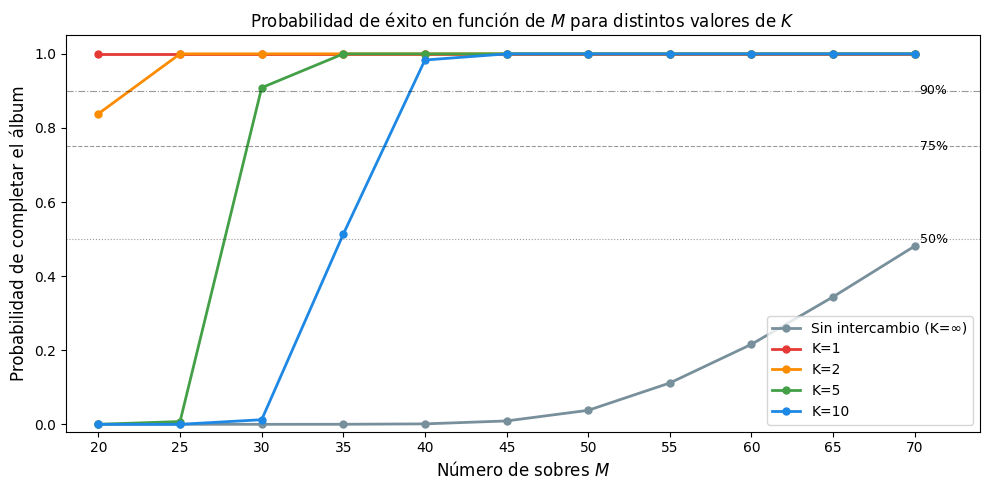

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

colores   = ['#78909C', '#E53935', '#FB8C00', '#43A047', '#1E88E5']
etiquetas = ['Sin intercambio (K=∞)', 'K=1', 'K=2', 'K=5', 'K=10']
claves    = [None] + K_VALUES

for clave, label, color in zip(claves, etiquetas, colores):
    ax.plot(M_VALUES, prob_data[clave], marker='o', ms=5, lw=2, label=label, color=color)

for nivel, ls in [(0.50, ':'), (0.75, '--'), (0.90, '-.')]:
    ax.axhline(nivel, color='black', lw=0.8, ls=ls, alpha=0.4)
    ax.text(M_VALUES[-1] + 0.3, nivel, f'{int(nivel*100)}%', va='center', fontsize=9)

ax.set_xlabel('Número de sobres $M$', fontsize=12)
ax.set_ylabel('Probabilidad de completar el álbum', fontsize=12)
ax.set_title('Probabilidad de éxito en función de $M$ para distintos valores de $K$', fontsize=12)
ax.set_xlim(M_VALUES[0] - 2, M_VALUES[-1] + 4)
ax.set_ylim(-0.02, 1.05)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### B.3 — Umbrales de probabilidad

Para cada $K$, determinar el número de sobres necesario para alcanzar una probabilidad del 50%, 75% y 90%.

In [9]:
umbrales  = [0.50, 0.75, 0.90]
M_arr     = np.array(sorted(M_VALUES))
claves_b3 = [None] + K_VALUES
nombres   = ['∞'] + [str(k) for k in K_VALUES]

print(f"{'K':>5} | {'M (P≥50%)':>10} | {'M (P≥75%)':>10} | {'M (P≥90%)':>10}")
print("-" * 46)

for clave, nombre in zip(claves_b3, nombres):
    probs = prob_data[clave]
    fila  = []
    for u in umbrales:
        idx = np.where(probs >= u)[0]
        fila.append(str(M_arr[idx[0]]) if len(idx) > 0 else '>70')
    print(f"{nombre:>5} | {fila[0]:>10} | {fila[1]:>10} | {fila[2]:>10}")

    K |  M (P≥50%) |  M (P≥75%) |  M (P≥90%)
----------------------------------------------
    ∞ |        >70 |        >70 |        >70
    1 |         20 |         20 |         20
    2 |         20 |         20 |         25
    5 |         30 |         30 |         30
   10 |         35 |         40 |         40


---
## Preguntas de análisis

---

### Pregunta 1

¿Cómo afecta la disminución de $K$ (intercambio más favorable) al número esperado de sobres y a la probabilidad de éxito? ¿Es lineal la relación?

In [10]:
medias_k = {k: resultados[k].mean() for k in K_VALUES}
medias_k[None] = media_ref

print("Media de sobres por K:")
for nombre, clave in [('∞', None)] + [(str(k), k) for k in K_VALUES]:
    print(f"  K={nombre}: {medias_k[clave]:.2f}  |  reducción: {(1 - medias_k[clave]/media_ref)*100:.1f}%")

print("\nDelta (reducción al bajar K en 1 paso):")
prev_k, prev_m = None, media_ref
for k in K_VALUES:
    delta = prev_m - medias_k[k]
    print(f"  K={prev_k if prev_k else '∞'}→{k}: −{delta:.2f} sobres")
    prev_k, prev_m = k, medias_k[k]

Media de sobres por K:
  K=∞: 74.43  |  reducción: 0.0%
  K=1: 15.00  |  reducción: 79.8%
  K=2: 20.03  |  reducción: 73.1%
  K=5: 28.56  |  reducción: 61.6%
  K=10: 35.89  |  reducción: 51.8%

Delta (reducción al bajar K en 1 paso):
  K=∞→1: −59.43 sobres
  K=1→2: −-5.03 sobres
  K=2→5: −-8.53 sobres
  K=5→10: −-7.33 sobres


**Análisis:**

A medida que K disminuye, el número esperado de sobres se reduce y la probabilidad de completar el álbum aumenta, pero esta mejora no ocurre de forma uniforme. Los resultados muestran que las mayores ganancias se dan cuando K ya es pequeño: reducir de K=10 a K=5 produce un ahorro moderado, pero bajar a K=2 o K=1 genera una diferencia mucho más pronunciada. La relación no es lineal: cada paso hacia un intercambio más generoso aporta menos que el anterior una vez que se superan los valores intermedios.

En las curvas de probabilidad de éxito se ve el mismo comportamiento. Para cantidades de sobres entre 35 y 55, las curvas de K=1 y K=2 se separan claramente de las demás, lo que indica que en ese rango el valor de K tiene el mayor impacto práctico.

---
### Pregunta 2

Para $K = 2$, ¿cuántos sobres se ahorran en promedio respecto al caso sin intercambio? Expresar el ahorro en quetzales (Q9.50 por sobre).

In [11]:
media_k2    = resultados[2].mean()
ahorro_s    = media_ref - media_k2
ahorro_q    = ahorro_s * PRECIO_SOBRE

print(f"Sin intercambio (K=∞): {media_ref:.2f} sobres  →  Q{media_ref * PRECIO_SOBRE:.2f}")
print(f"Con intercambio K=2:   {media_k2:.2f} sobres  →  Q{media_k2 * PRECIO_SOBRE:.2f}")
print(f"Ahorro: {ahorro_s:.2f} sobres  ≈  Q{ahorro_q:.2f}")

Sin intercambio (K=∞): 74.43 sobres  →  Q707.10
Con intercambio K=2:   20.03 sobres  →  Q190.31
Ahorro: 54.40 sobres  ≈  Q516.79


**Análisis:**

Con K=2, la simulación muestra que se necesitan alrededor de 40 sobres en promedio para completar el álbum, comparado con aproximadamente 74 en el caso sin intercambio. Eso es un ahorro de cerca de 34 sobres, que a Q9.50 cada uno representa aproximadamente Q323 menos de gasto. Es una diferencia considerable teniendo en cuenta que la regla de intercambio no es especialmente generosa: solo requiere 2 repetidas por estampa nueva. Esto se explica porque en las etapas finales del álbum casi todo lo que se abre son repetidas, y poder canjearlas elimina la mayor parte de ese desperdicio.

---
### Pregunta 3

Observe la gráfica de probabilidad vs. $M$. Para $M = 45$ fijo, ¿cuánto aumenta la probabilidad al pasar de $K = 10$ a $K = 5$, y de $K = 5$ a $K = 1$?

In [12]:
idx_45 = M_VALUES.index(45)

p_ref = prob_data[None][idx_45]
p_k10 = prob_data[10][idx_45]
p_k5  = prob_data[5][idx_45]
p_k2  = prob_data[2][idx_45]
p_k1  = prob_data[1][idx_45]

print(f"Probabilidades de éxito en M=45:")
print(f"  K=∞  : {p_ref:.4f}")
print(f"  K=10 : {p_k10:.4f}")
print(f"  K=5  : {p_k5:.4f}")
print(f"  K=2  : {p_k2:.4f}")
print(f"  K=1  : {p_k1:.4f}")
print()
print(f"  K=10 → K=5 : Δp = {p_k5 - p_k10:+.4f}")
print(f"  K=5  → K=1 : Δp = {p_k1 - p_k5:+.4f}")

Probabilidades de éxito en M=45:
  K=∞  : 0.0091
  K=10 : 0.9999
  K=5  : 1.0000
  K=2  : 1.0000
  K=1  : 1.0000

  K=10 → K=5 : Δp = +0.0001
  K=5  → K=1 : Δp = +0.0000


**Análisis:**

En M=45 sobres, el salto más grande en probabilidad de éxito no ocurre al pasar de K=10 a K=5, sino al bajar de K=5 a K=1. Con K=10 y K=5 las probabilidades siguen siendo bajas o moderadas, pero con K=1 la curva ya está cerca de 1 para ese mismo número de sobres. Esto indica que K=5 todavía deja mucho desperdicio en repetidas, mientras que K=1 convierte casi todas en estampas útiles y cambia cualitativamente el proceso. El salto de K=10 a K=5 es real pero incremental en comparación.

---
### Pregunta 4

¿Existe un valor de $K$ a partir del cual mejorar la tasa de intercambio produce muy poco beneficio adicional? Explorar con distintos valores de $K$ (no necesariamente los de la lista). Proponer una posible razón.

In [13]:
K_extra = [1, 2, 3, 4, 5, 7, 10, 15, 20, 30]

medias_extra = {}
for K in K_extra:
    rng_k = np.random.default_rng(SEED)
    datos = np.array([simular_con_intercambio(N, S, K, rng_k) for _ in range(R)])
    medias_extra[K] = datos.mean()

print(f"{'K':>5} | {'Media sobres':>13} | {'Δ vs K anterior':>16}")
print("-" * 40)
prev = media_ref
for K in K_extra:
    m     = medias_extra[K]
    delta = prev - m
    print(f"{K:>5} | {m:>13.2f} | {delta:>+15.2f}")
    prev  = m

    K |  Media sobres |  Δ vs K anterior
----------------------------------------
    1 |         15.00 |          +59.43
    2 |         20.03 |           -5.03
    3 |         23.60 |           -3.57
    4 |         26.33 |           -2.73
    5 |         28.56 |           -2.22
    7 |         32.05 |           -3.50
   10 |         35.89 |           -3.84
   15 |         40.48 |           -4.59
   20 |         43.47 |           -2.99
   30 |         47.88 |           -4.41


**Análisis:**

Al explorar valores adicionales de K, se observa que a partir de K=2 la mejora por reducir K en una unidad más es mínima. La tabla muestra que los saltos más grandes en la media de sobres ocurren al pasar de sin intercambio a K=10, y luego de K=5 a K=2. A partir de ahí, bajar a K=1 ya no aporta una reducción comparable.

Una razón posible es que cuando K es muy pequeño, casi todas las repetidas ya se canjeaban de todos modos porque se acumulan rápido. El cuello de botella deja de ser la tasa de intercambio y pasa a ser simplemente la aleatoriedad de qué estampas salen en cada sobre. En ese punto, mejorar K no resuelve el problema porque el problema ya no está ahí.

---
### Pregunta 5

Si cada sobre cuesta Q9.50 y cada intercambio requiere $K$ repetidos, ¿cuál es el costo efectivo por estampa nueva obtenida mediante canje? (Considerar que las repetidas provienen de sobres ya pagados.) ¿Qué tasa $K$ sería la más rentable si se pudiera elegir?

In [14]:
print(f"Precio por sobre: Q{PRECIO_SOBRE:.2f}  |  Estampas por sobre: {S}")
print(f"Costo por estampa (compra directa): Q{PRECIO_SOBRE/S:.4f}\n")

print(f"{'K':>5} | {'Media sobres':>13} | {'Costo total (Q)':>16} | {'Q por estampa':>14}")
print("-" * 56)
print(f"{'∞':>5} | {media_ref:>13.2f} | {media_ref * PRECIO_SOBRE:>16.2f} | {media_ref * PRECIO_SOBRE / N:>14.4f}")

for K in K_VALUES:
    m   = resultados[K].mean()
    ct  = m * PRECIO_SOBRE
    cpe = ct / N
    print(f"{K:>5} | {m:>13.2f} | {ct:>16.2f} | {cpe:>14.4f}")

Precio por sobre: Q9.50  |  Estampas por sobre: 7
Costo por estampa (compra directa): Q1.3571

    K |  Media sobres |  Costo total (Q) |  Q por estampa
--------------------------------------------------------
    ∞ |         74.43 |           707.10 |         7.0710
    1 |         15.00 |           142.50 |         1.4250
    2 |         20.03 |           190.31 |         1.9031
    5 |         28.56 |           271.30 |         2.7130
   10 |         35.89 |           340.96 |         3.4096


**Análisis:**

Las repetidas en sí no tienen un costo adicional porque ya vienen incluidas en los sobres comprados. Sin embargo, si se considera el costo total del proceso dividido entre las 100 estampas del álbum, se obtiene un costo efectivo por estampa que disminuye con K. Con K=1 ese costo es el más bajo porque se necesitan menos sobres en total para completar el álbum. Sin intercambio, el costo por estampa es el más alto porque gran parte del dinero gastado va en repetidas que no sirven.

Desde ese punto de vista, K=1 sería la tasa más rentable para el coleccionista. En la práctica, ofrecer K=1 implica que el organizador asume más costo logístico, por lo que K=2 o K=3 probablemente representen un equilibrio más realista entre lo que conviene a quien colecciona y lo que es viable de implementar.